## Feature Importance for Dragon Features

<class 'list'>
25
dict_keys(['repeat', 'fold', 'best_n_estimator', 'best_max_depth', 'feature_names', 'feature_importances'])
Importance matrix shape: (25, 9)


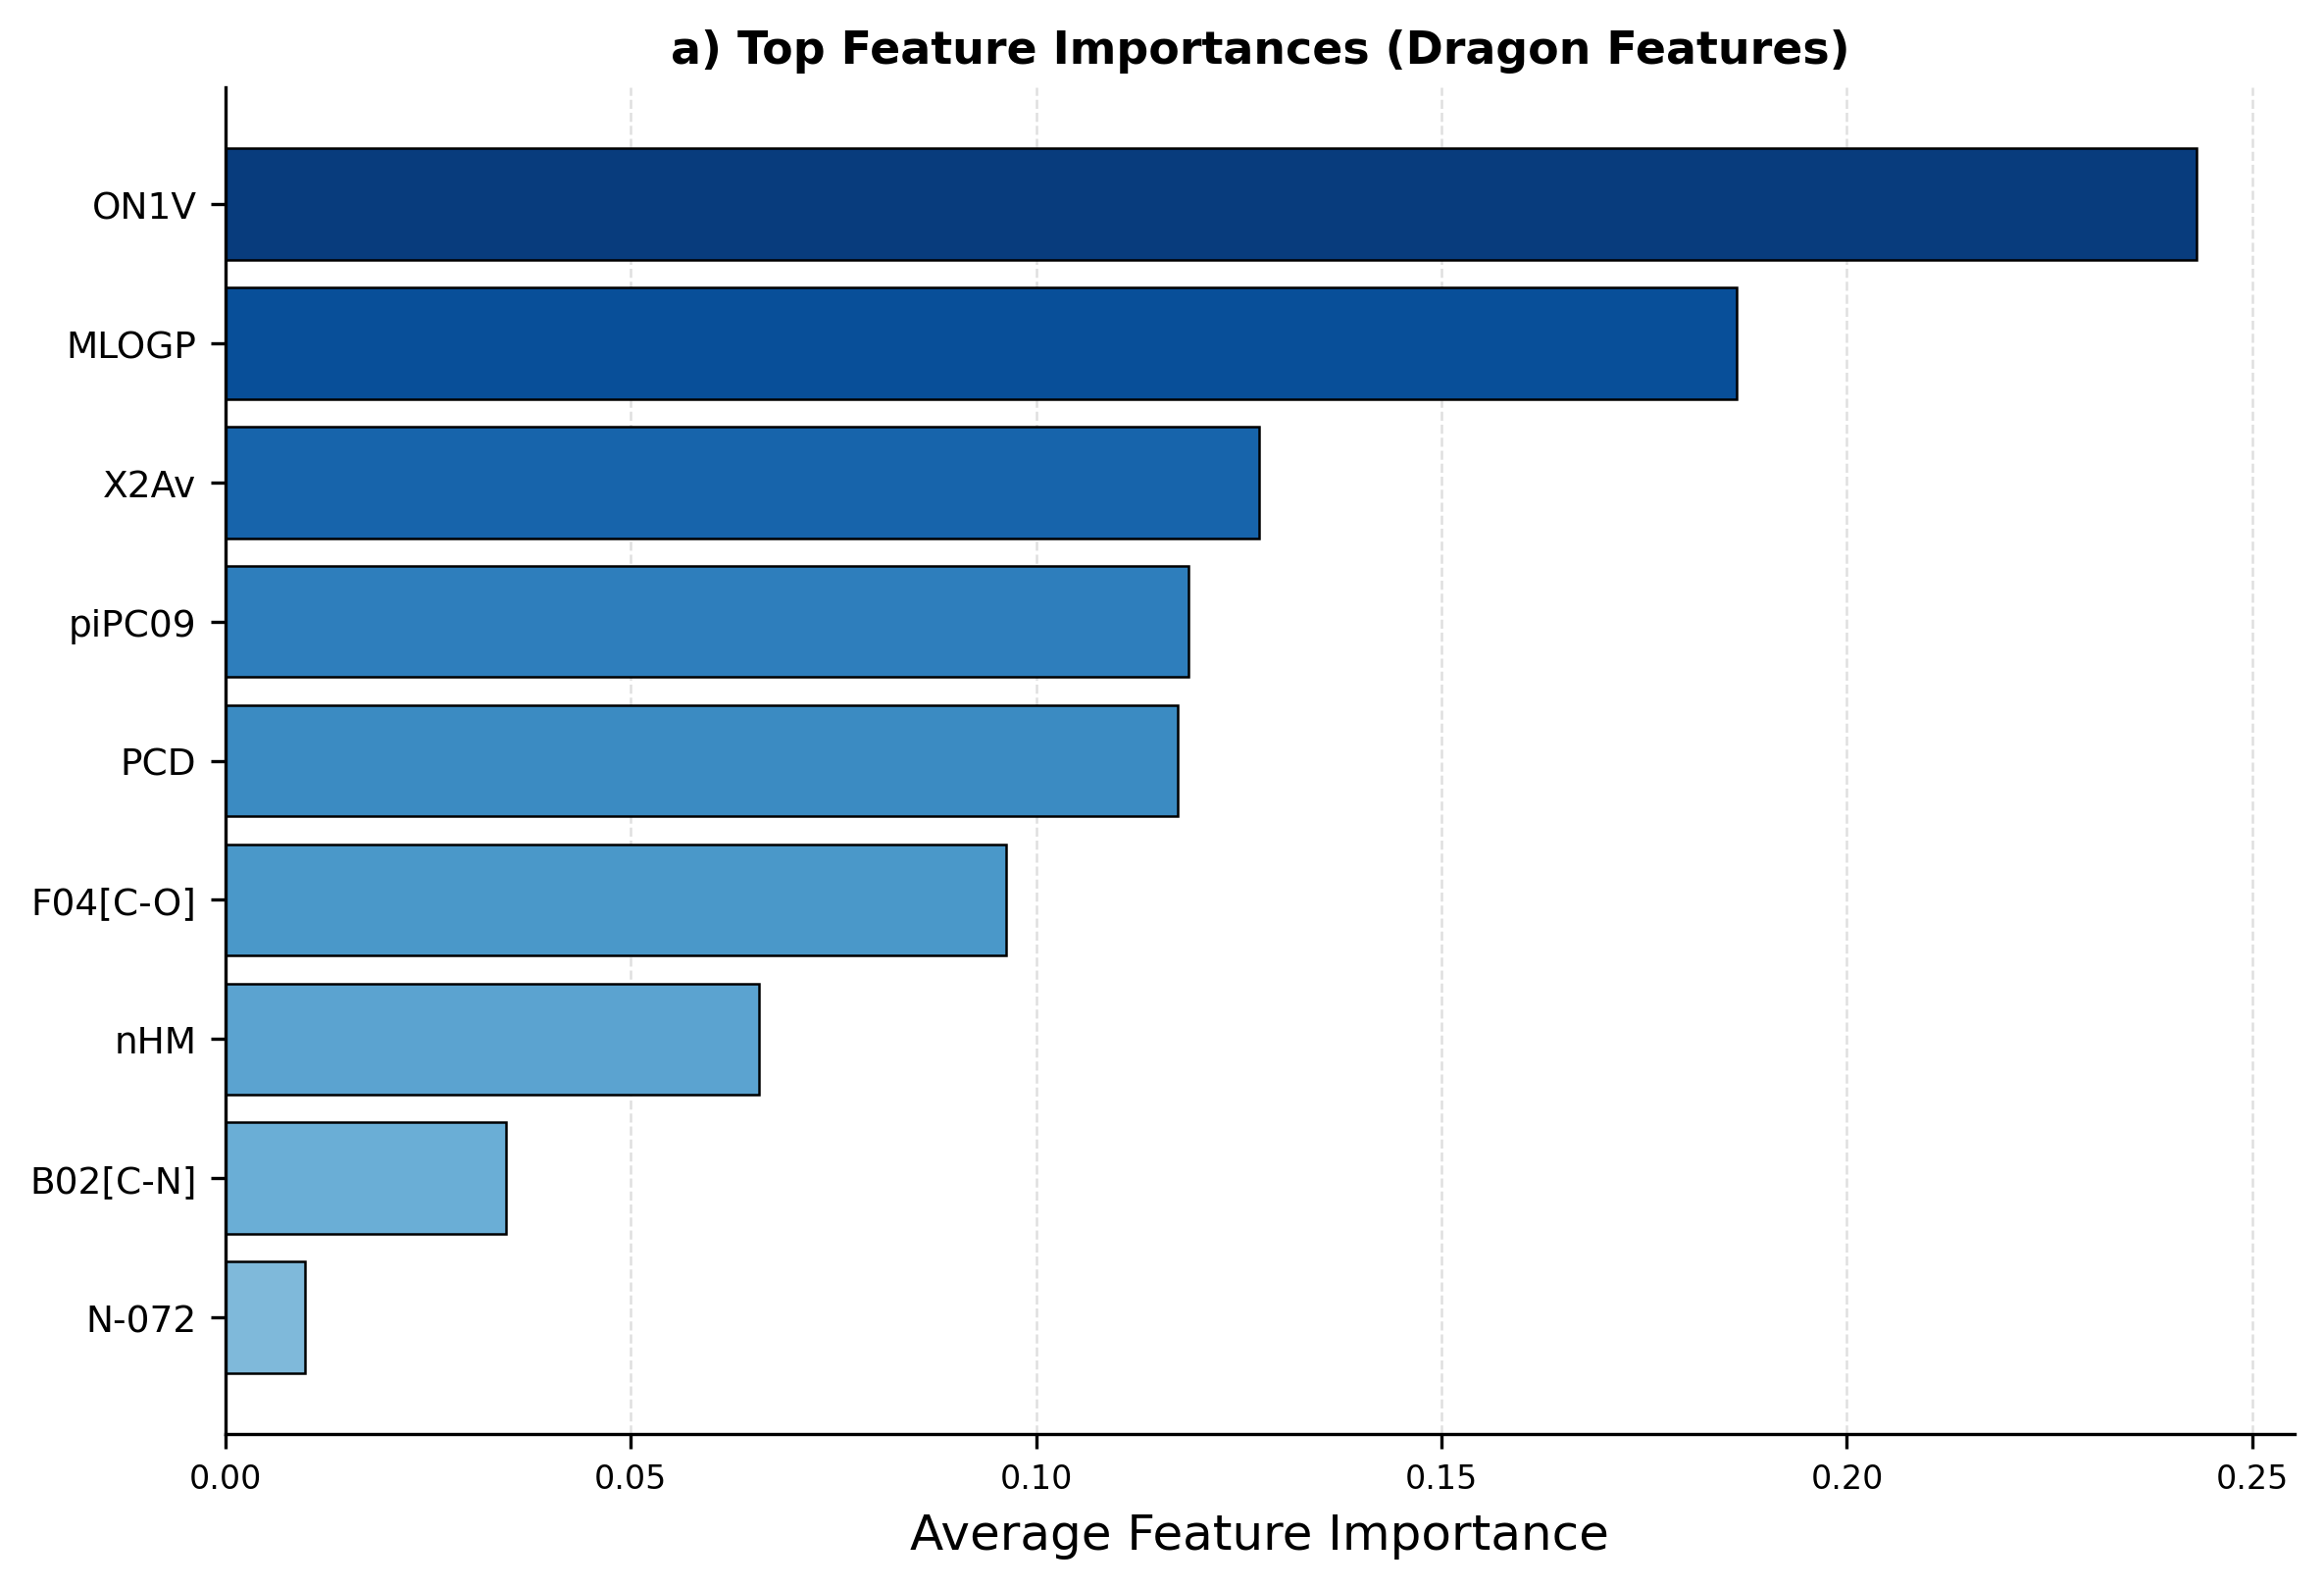

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Load the pickle file
with open("all_feature_importances_rf_panela.pkl", "rb") as f:
    all_feature_importances = pickle.load(f)

# Inspect structure
print(type(all_feature_importances))
print(len(all_feature_importances))
print(all_feature_importances[0].keys())

# Extract feature names
feature_names = all_feature_importances[0]["feature_names"]

# Check that feature names are consistent across all models
for i, item in enumerate(all_feature_importances):
    if not np.array_equal(item["feature_names"], feature_names):
        raise ValueError(f"Feature names differ in model {i}")

# Extract feature importance arrays
importance_matrix = np.array([
    item["feature_importances"] for item in all_feature_importances
])

print("Importance matrix shape:", importance_matrix.shape)

# Average feature importance across all 25 models
avg_importances = np.mean(importance_matrix, axis=0)

# Select top features
top_n = min(9, len(feature_names))

sorted_idx = np.argsort(avg_importances)[::-1][:top_n]
sorted_importances = avg_importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Reverse for horizontal bar plot
sorted_importances = sorted_importances[::-1]
sorted_features = sorted_features[::-1]

# Create color gradient
cmap = cm.Blues
colors = cmap(np.linspace(0.45, 0.85, top_n))

# Highlight top 3 features with darker shades
colors[-1] = cmap(0.95)
colors[-2] = cmap(0.88)
colors[-3] = cmap(0.80)

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)

bars = ax.barh(
    sorted_features,
    sorted_importances,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

ax.set_xlabel("Average Feature Importance", fontsize=12)
ax.set_title("a) Top Feature Importances (Dragon Features)", fontsize=11, weight="bold")

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Feature Importance for RDKit Features

Importance matrix shape: (25, 198)
Number of feature names: 198


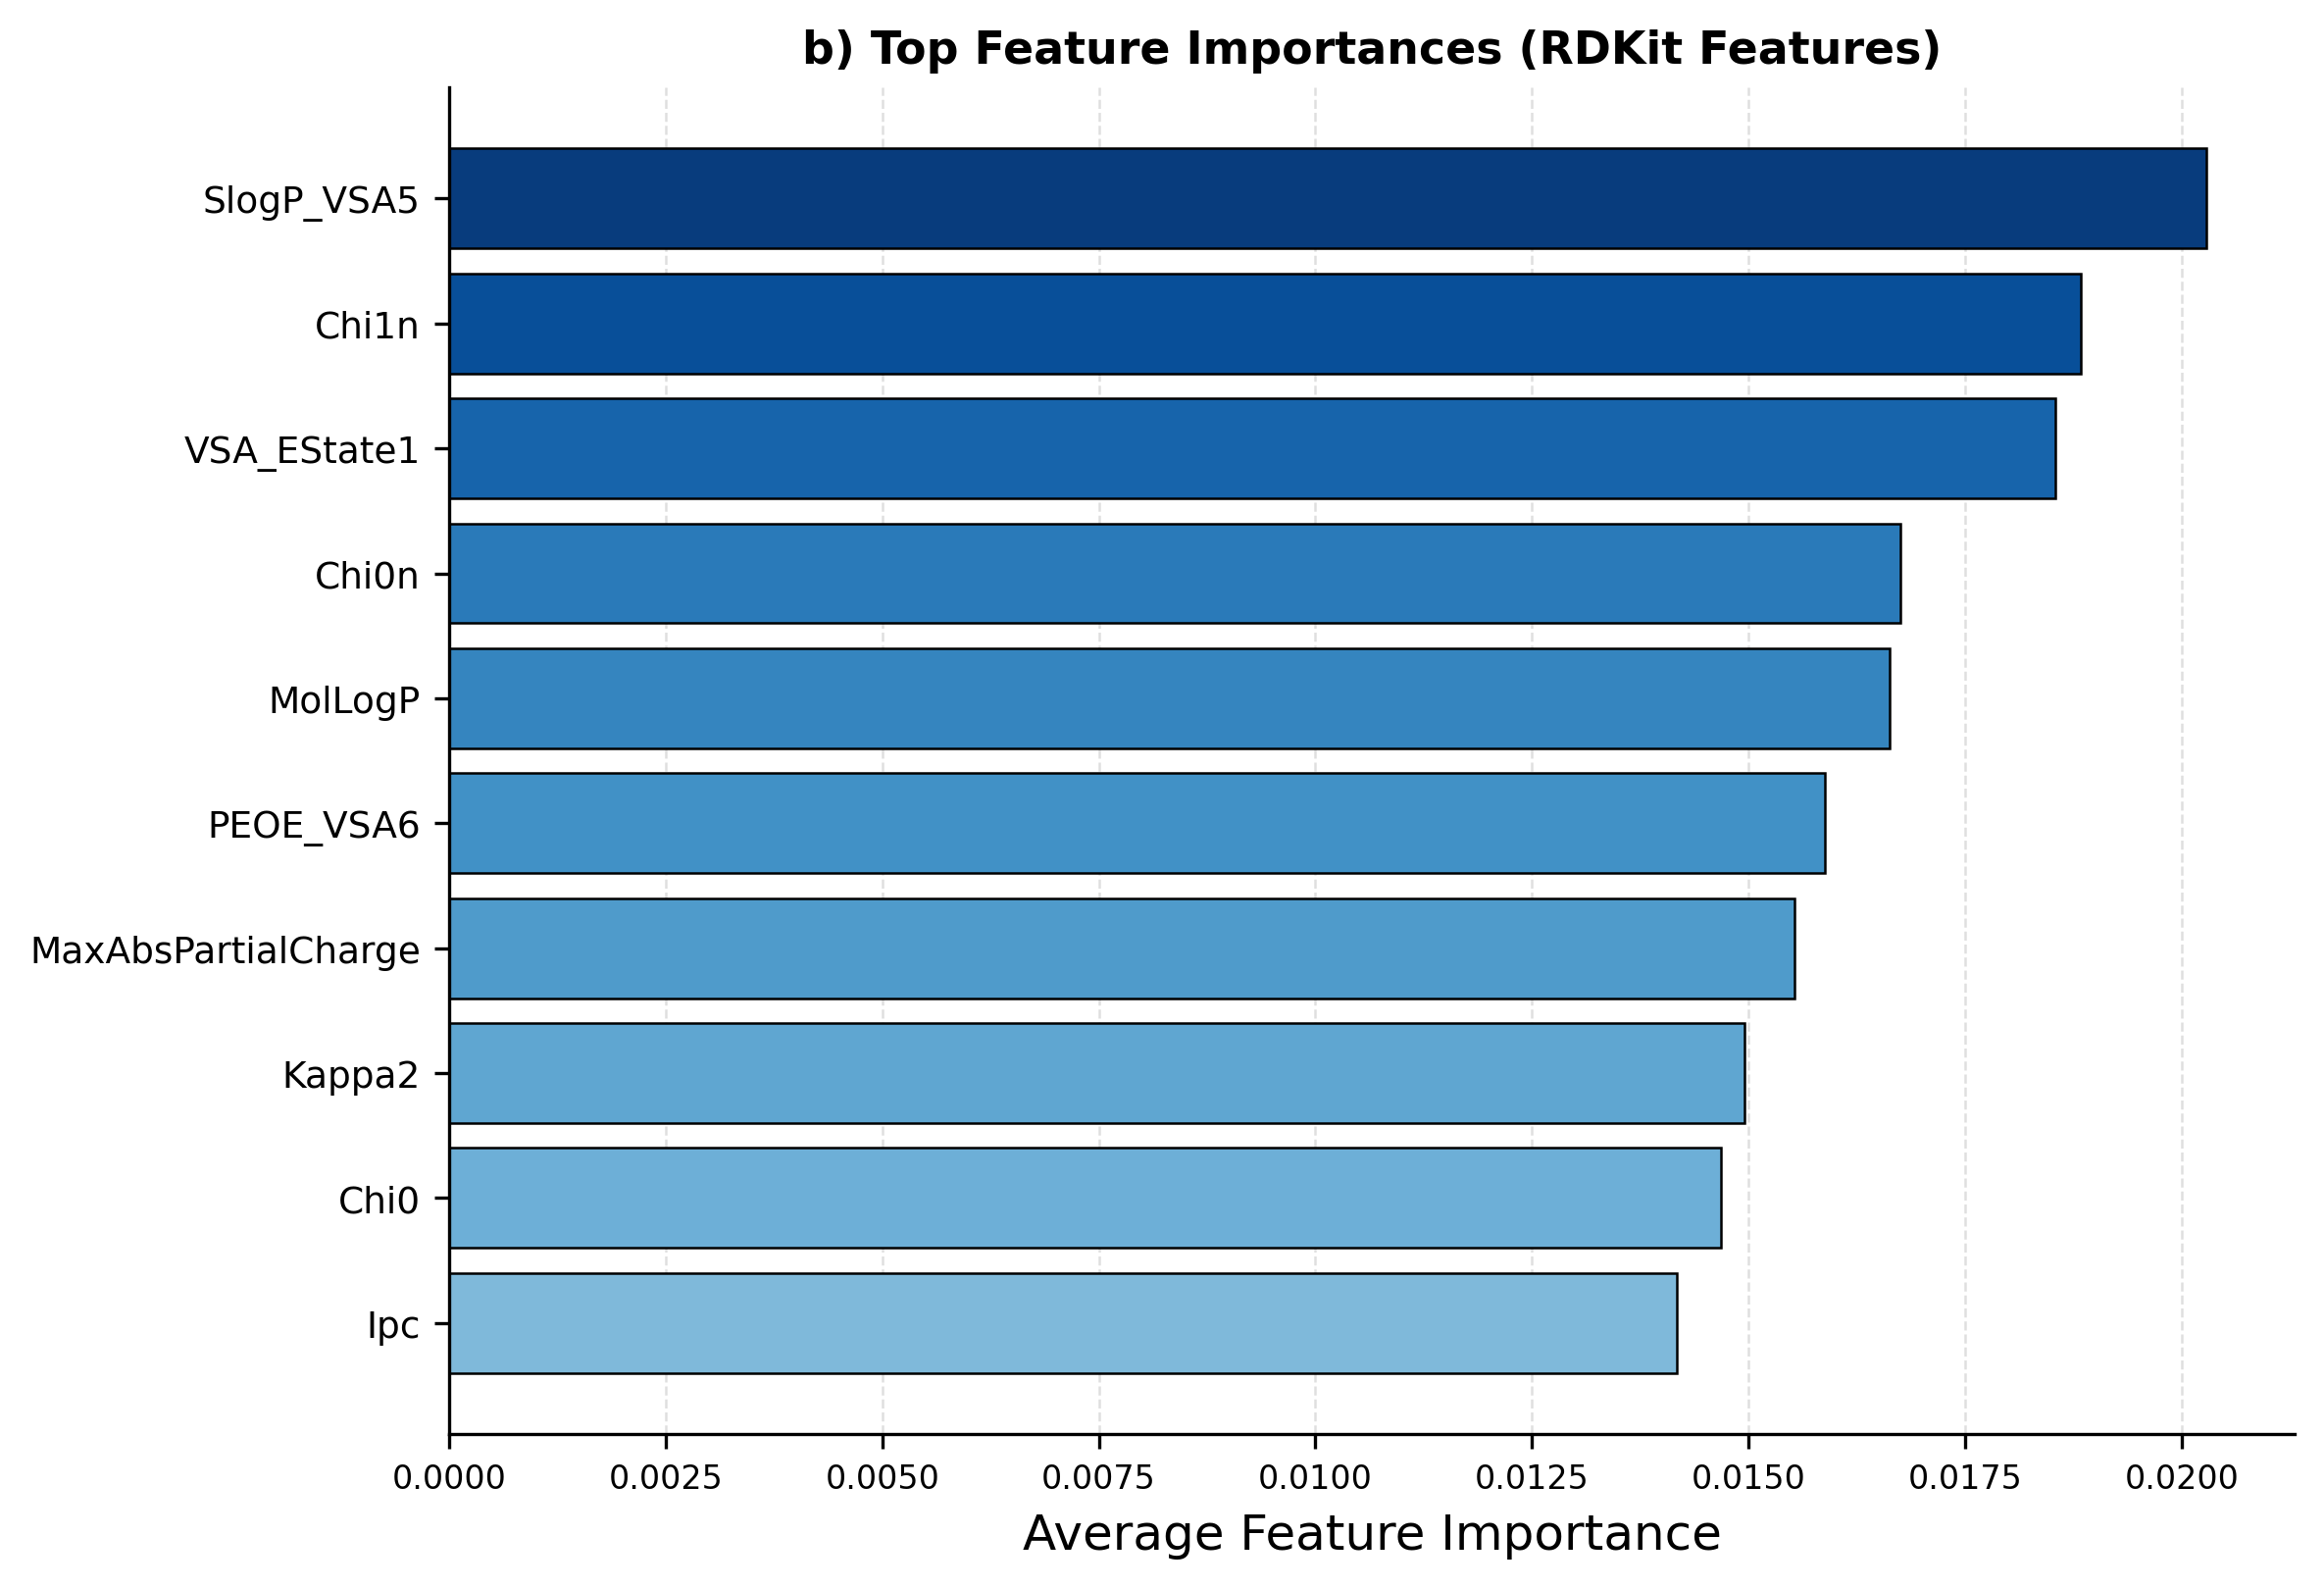

In [ ]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Load RDKit data to get the correct feature names
data = pd.read_csv("rdkit_data.csv")

features = data.drop(
    columns=["CAS", "QSAR_READY_SMILES", "mol", "Class"]
)

feature_names = features.columns.to_numpy()

# Load the pickle file
with open("all_feature_importances_rf_panelb.pkl", "rb") as f:
    all_feature_importances = pickle.load(f)

# This pickle is a list of NumPy arrays
importance_matrix = np.array(all_feature_importances)

print("Importance matrix shape:", importance_matrix.shape)
print("Number of feature names:", len(feature_names))

# Safety check
if importance_matrix.shape[1] != len(feature_names):
    raise ValueError(
        f"Mismatch: pickle has {importance_matrix.shape[1]} importances, "
        f"but RDKit feature table has {len(feature_names)} feature names."
    )

# Average feature importance across all models
avg_importances = np.mean(importance_matrix, axis=0)

# Select top features
top_n = min(10, len(feature_names))

sorted_idx = np.argsort(avg_importances)[::-1][:top_n]
sorted_importances = avg_importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Reverse for horizontal bar plot
sorted_importances = sorted_importances[::-1]
sorted_features = sorted_features[::-1]

# Create color gradient
cmap = cm.Blues
colors = cmap(np.linspace(0.45, 0.85, top_n))

# Highlight top 3 features with darker shades
colors[-1] = cmap(0.95)
colors[-2] = cmap(0.88)
colors[-3] = cmap(0.80)

# Plot
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=300)

bars = ax.barh(
    sorted_features,
    sorted_importances,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

ax.set_xlabel("Average Feature Importance", fontsize=12)
ax.set_title("b) Top Feature Importances (RDKit Features)", fontsize=11, weight="bold")

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=8)

ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()